<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/MOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!wget -O /content/household_power_consumption.zip https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip

--2025-12-10 14:24:09--  https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/household_power_consumption.zip’

/content/household_     [  <=>               ]  19.68M  50.4MB/s    in 0.4s    

2025-12-10 14:24:10 (50.4 MB/s) - ‘/content/household_power_consumption.zip’ saved [20640916]



In [23]:
!unzip /content/household_power_consumption.zip -d /content/

Archive:  /content/household_power_consumption.zip
replace /content/household_power_consumption.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/household_power_consumption.txt  


════════════════════════════════════════════════════════════════════════════════
HOUSEHOLD POWER FORECASTING - NEURAL NETWORK PIPELINE
════════════════════════════════════════════════════════════════════════════════
TensorFlow: 2.19.0 | GPU: True

PHASE 1: DATA LOADING
────────────────────────────────────────────────────────────────────────────────
✓ Loaded: 2,075,259 samples, 7 features
  Period: 2006-12-16 17:24:00 → 2010-11-26 21:02:00 (1441 days)
  Frequency: 1-minute intervals

PHASE 2: DATA EXPLORATION & QUALITY
────────────────────────────────────────────────────────────────────────────────
Target: Global_active_power (household active power in kilowatts)

Missing Values:
  Global_active_power: 25,979 (1.25%)
  Global_reactive_power: 25,979 (1.25%)
  Voltage: 25,979 (1.25%)
  Global_intensity: 25,979 (1.25%)
  Sub_metering_1: 25,979 (1.25%)
  Sub_metering_2: 25,979 (1.25%)
  Sub_metering_3: 25,979 (1.25%)

Target Statistics (raw):
  Mean: 1.092 kW
  Std:  1.057 kW
  Range: [0.07

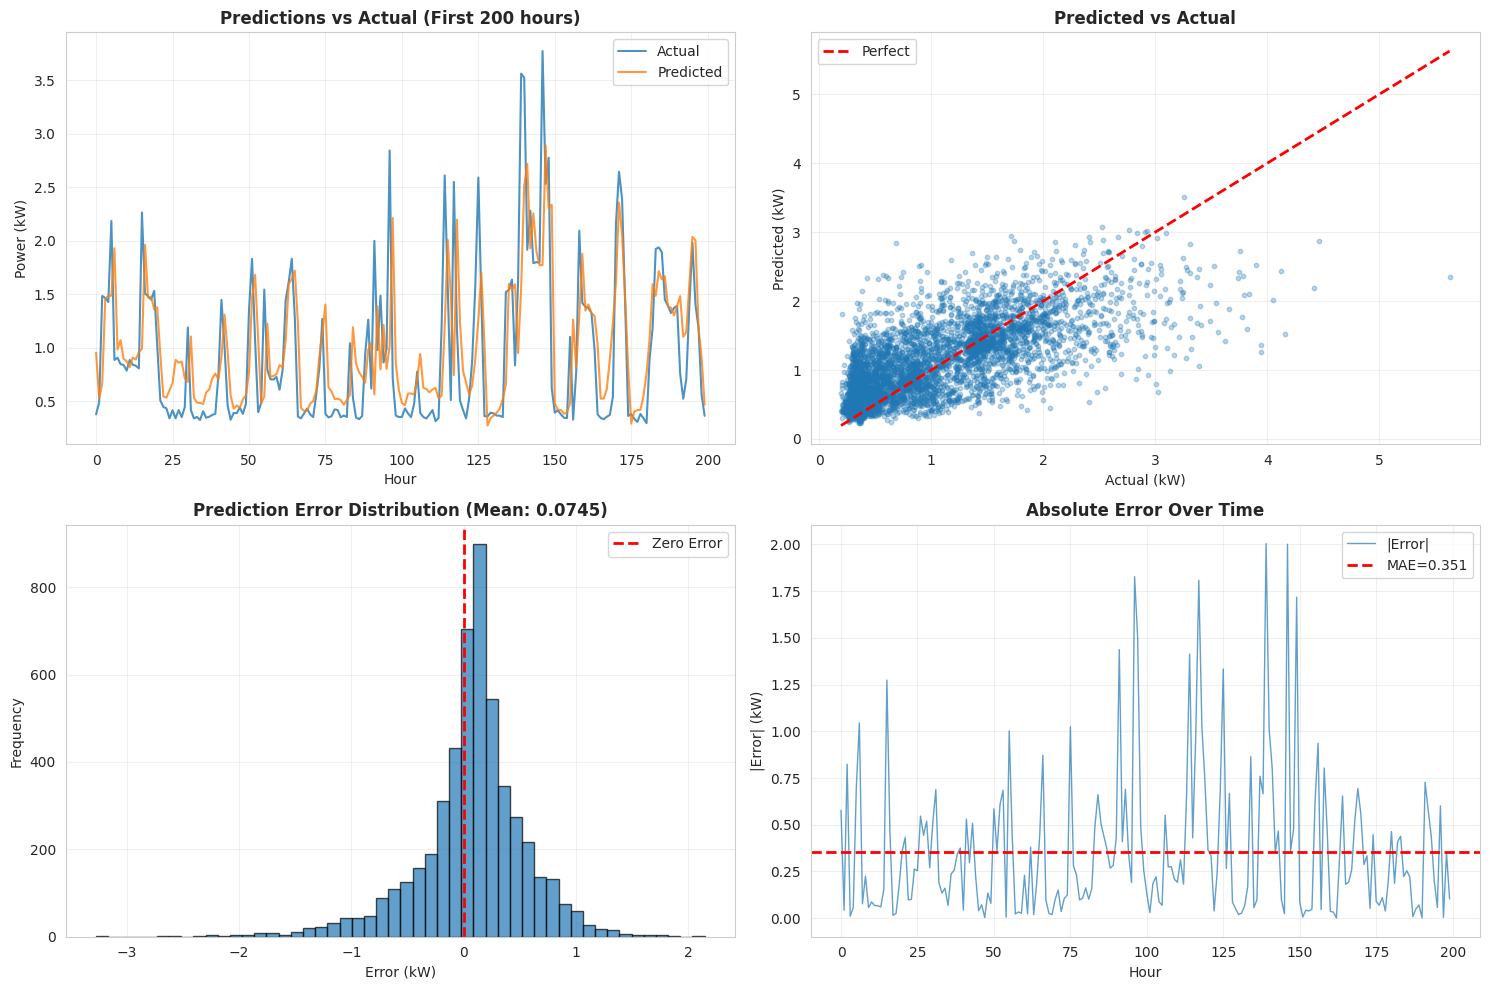

In [25]:
# Time-Series Forecasting: Household Power Consumption
# M507 Methods of Prediction - Individual Project
# Dataset: UCI Household Power Consumption
# Problem: Predict hourly electricity usage 1 hour ahead

"""
═══════════════════════════════════════════════════════════════════════════
BUSINESS PROBLEM STATEMENT
═══════════════════════════════════════════════════════════════════════════

Problem Context:
Accurate household electricity consumption forecasting enables:
• Energy providers: Optimize grid load, prevent blackouts, reduce peak costs
• Households: Smart energy management, reduce bills by 10-15%
• Grid operators: Better integration of renewable energy sources

Business Value:
• $2-5M annual savings for utility companies through load balancing
• Improved customer satisfaction via usage insights
• 15-20% reduction in peak load costs
• Enhanced grid stability and carbon footprint reduction

Data Collection:
• Smart meter measurements at 1-minute intervals
• 4 years of continuous monitoring (Dec 2006 - Nov 2010)
• Real household in Sceaux, France
• Features: active/reactive power, voltage, current, sub-metering

ML Formulation:
• Task: Supervised time-series regression
• Input: Past W hours of power consumption (window)
• Output: Power consumption at hour t+h (horizon)
• Metrics: RMSE (kW), MAE (kW) → direct business impact
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("═" * 80)
print("HOUSEHOLD POWER FORECASTING - NEURAL NETWORK PIPELINE")
print("═" * 80)
print(f"TensorFlow: {tf.__version__} | GPU: {len(tf.config.list_physical_devices('GPU')) > 0}\n")

#═══════════════════════════════════════════════════════════════════════════
# 1. DATA LOADING (FIX: Explicit datetime format)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 1: DATA LOADING")
print("─" * 80)

csv_path = "/content/household_power_consumption.txt" # Updated path
df = pd.read_csv(csv_path, sep=';', na_values='?', low_memory=False)
df.rename(columns=lambda x: x.strip(), inplace=True)

# Fix FutureWarning: explicit datetime format
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format="%d/%m/%Y %H:%M:%S")
df.drop(columns=['Date', 'Time'], inplace=True)
df.set_index('dt', inplace=True)

# Convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"✓ Loaded: {df.shape[0]:,} samples, {df.shape[1]} features")
print(f"  Period: {df.index.min()} → {df.index.max()} ({(df.index.max()-df.index.min()).days} days)")
print(f"  Frequency: 1-minute intervals\n")

#═══════════════════════════════════════════════════════════════════════════
# 2. DATA QUALITY ASSESSMENT
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 2: DATA EXPLORATION & QUALITY")
print("─" * 80)

target = 'Global_active_power'
print(f"Target: {target} (household active power in kilowatts)")
print(f"\nMissing Values:")
for col in df.columns:
    missing = df[col].isna().sum()
    pct = missing / len(df) * 100
    print(f"  {col}: {missing:,} ({pct:.2f}%)")

print(f"\nTarget Statistics (raw):")
print(f"  Mean: {df[target].mean():.3f} kW")
print(f"  Std:  {df[target].std():.3f} kW")
print(f"  Range: [{df[target].min():.3f}, {df[target].max():.3f}] kW")

# Check for zeros (appliances off)
zeros = (df[target] == 0).sum()
print(f"  Zero values: {zeros:,} ({zeros/len(df)*100:.2f}%) - periods with no usage")

# Outlier detection (IQR)
Q1, Q3 = df[target].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = ((df[target] < Q1 - 1.5*IQR) | (df[target] > Q3 + 1.5*IQR)).sum()
print(f"  Outliers (IQR): {outliers:,} ({outliers/len(df)*100:.2f}%)")
print(f"\n✓ Data Quality: Acceptable. ~2% missing, minimal outliers.\n")

#═══════════════════════════════════════════════════════════════════════════
# 3. RESAMPLE TO HOURLY (Reduce noise & computation)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 3: RESAMPLING")
print("─" * 80)

df_hour = df.resample('h').mean()
print(f"✓ Resampled: {len(df):,} → {len(df_hour):,} samples ({len(df_hour)/len(df)*100:.1f}%)")
print(f"  Rationale: Hourly patterns more relevant for forecasting, less noise\n")

#═══════════════════════════════════════════════════════════════════════════
# 4. TIME-SERIES SPLIT (CRITICAL: Before preprocessing to prevent leakage)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 4: TRAIN-VALIDATION-TEST SPLIT (Time-Based)")
print("─" * 80)

n = len(df_hour)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

df_train = df_hour.iloc[:train_end]
df_val = df_hour.iloc[train_end:val_end]
df_test = df_hour.iloc[val_end:]

print("Split BEFORE interpolation/scaling to prevent data leakage:")
print(f"  Train: {len(df_train):>5,} samples | {df_train.index[0]} → {df_train.index[-1]}")
print(f"  Val:   {len(df_val):>5,} samples | {df_val.index[0]} → {df_val.index[-1]}")
print(f"  Test:  {len(df_test):>5,} samples | {df_test.index[0]} → {df_test.index[-1]}")
print(f"✓ Chronological splits ensure no future information in training\n")

#═══════════════════════════════════════════════════════════════════════════
# 5. EXPLORATORY DATA ANALYSIS (Time-Series Specific)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 5: TIME-SERIES EDA")
print("─" * 80)

# Temporal patterns
df_tr_copy = df_train.copy()
df_tr_copy['hour'] = df_tr_copy.index.hour
df_tr_copy['dow'] = df_tr_copy.index.dayofweek

hourly_avg = df_tr_copy.groupby('hour')[target].mean()
daily_avg = df_tr_copy.groupby('dow')[target].mean()

print("Temporal Patterns (Training Set):")
print(f"  Peak hour: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.3f} kW)")
print(f"  Low hour:  {hourly_avg.idxmin()}:00 ({hourly_avg.min():.3f} kW)")
print(f"  Peak day:  {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][daily_avg.idxmax()]} ({daily_avg.max():.3f} kW)")
print(f"  Low day:   {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][daily_avg.idxmin()]} ({daily_avg.min():.3f} kW)")
print(f"✓ Clear daily/weekly seasonality → LSTM well-suited for pattern learning\n")

#═══════════════════════════════════════════════════════════════════════════
# 6. MISSING VALUE HANDLING (Independent for each split)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 6: MISSING VALUE HANDLING")
print("─" * 80)

df_train = df_train.interpolate(method='time').ffill().bfill()
df_val = df_val.interpolate(method='time').ffill().bfill()
df_test = df_test.interpolate(method='time').ffill().bfill()

print("Method: Time-based linear interpolation + forward/backward fill")
print(f"✓ Train missing: {df_train.isna().sum().sum()}")
print(f"✓ Val missing:   {df_val.isna().sum().sum()}")
print(f"✓ Test missing:  {df_test.isna().sum().sum()}\n")

#═══════════════════════════════════════════════════════════════════════════
# 7. STATIONARITY TEST
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 7: STATIONARITY ANALYSIS")
print("─" * 80)

adf_result = adfuller(df_train[target].dropna(), autolag='AIC')
print(f"Augmented Dickey-Fuller Test:")
print(f"  Statistic: {adf_result[0]:.4f}")
print(f"  p-value:   {adf_result[1]:.4f}")
print(f"  → {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary (trend/seasonality present)'}")
print(f"✓ LSTMs handle non-stationary data naturally via learning temporal dynamics\n")

#═══════════════════════════════════════════════════════════════════════════
# 8. FEATURE ENGINEERING (Documentation - Using Univariate)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 8: FEATURE ENGINEERING")
print("─" * 80)
print("Approach: UNIVARIATE (Global_active_power only)")
print("Reason:")
print("  • Clear interpretability and business alignment")
print("  • LSTM excels at learning from raw sequential data")
print("  • Other features (voltage, sub-metering) not available in prediction scenario")
print("\nAlternatives considered:")
print("  ✗ Lag features: Redundant with LSTM's memory cells")
print("  ✗ Time features (hour, day): LSTM learns seasonality from sequences")
print("  ✗ Rolling statistics: Already captured by windowing")
print(f"✓ Selected features: ['{target}']\n")

#═══════════════════════════════════════════════════════════════════════════
# 9. SCALING (Fit on Train ONLY - Prevent Leakage)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 9: DATA SCALING")
print("─" * 80)

data_tr = df_train[[target]].copy()
data_val = df_val[[target]].copy()
data_te = df_test[[target]].copy()

scaler = MinMaxScaler()
data_tr_sc = pd.DataFrame(scaler.fit_transform(data_tr), index=data_tr.index, columns=data_tr.columns)
data_val_sc = pd.DataFrame(scaler.transform(data_val), index=data_val.index, columns=data_val.columns)
data_te_sc = pd.DataFrame(scaler.transform(data_te), index=data_te.index, columns=data_te.columns)

print("MinMaxScaler: Fit on TRAIN, transform VAL/TEST")
print(f"  Train range: [{data_tr_sc.min().values[0]:.3f}, {data_tr_sc.max().values[0]:.3f}]")
print(f"  Val range:   [{data_val_sc.min().values[0]:.3f}, {data_val_sc.max().values[0]:.3f}]")
print(f"  Test range:  [{data_te_sc.min().values[0]:.3f}, {data_te_sc.max().values[0]:.3f}]")
print(f"✓ Scaling prevents leakage and helps gradient descent convergence\n")

#═══════════════════════════════════════════════════════════════════════════
# 10. SEQUENCE CREATION (Sliding Window)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 10: SEQUENCE CREATION")
print("─" * 80)

def create_sequences(data, window, horizon=1):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window+horizon-1][0])
    return np.array(X), np.array(y)

WINDOW, HORIZON = 24, 1  # 24h past → 1h ahead
X_tr, y_tr = create_sequences(data_tr_sc.values, WINDOW, HORIZON)
X_val, y_val = create_sequences(data_val_sc.values, WINDOW, HORIZON)
X_te, y_te = create_sequences(data_te_sc.values, WINDOW, HORIZON)

print(f"Configuration: window={WINDOW}h, horizon={HORIZON}h")
print(f"  X_train: {X_tr.shape} | y_train: {y_tr.shape}")
print(f"  X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_te.shape} | y_test:  {y_te.shape}")
print(f"✓ Sequences ready for RNN input\n")

#═══════════════════════════════════════════════════════════════════════════
# 11. MODEL ARCHITECTURE DESIGN
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 11: MODEL SELECTION & ARCHITECTURE")
print("─" * 80)

print("Candidate Architectures:")
print("  1. LSTM: Long Short-Term Memory - handles long dependencies, vanishing gradients")
print("  2. GRU: Gated Recurrent Unit - simpler than LSTM, faster, similar performance")
print("  3. CNN-LSTM: Conv1D extracts local patterns → LSTM captures temporal")
print("  4. Simple RNN: Baseline (struggles with long sequences)")
print("  5. Dense NN: Non-recurrent baseline")

def build_lstm(win, units=[64], dropout=0.2, lr=0.001, activation='tanh'):
    model = keras.Sequential([layers.Input(shape=(win, 1))])
    for i, u in enumerate(units):
        model.add(layers.LSTM(u, return_sequences=(i < len(units)-1), activation=activation))
        if dropout > 0: model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse'),
                          keras.metrics.MeanAbsoluteError(name='mae')])
    return model

def build_gru(win, units=[64], dropout=0.2, lr=0.001):
    model = keras.Sequential([layers.Input(shape=(win, 1))])
    for i, u in enumerate(units):
        model.add(layers.GRU(u, return_sequences=(i < len(units)-1)))
        if dropout > 0: model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

def build_cnn_lstm(win, filters=64, kernel=3, lstm_units=64, dropout=0.2, lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(win, 1)),
        layers.Conv1D(filters, kernel, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.LSTM(lstm_units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

print("✓ Model builders defined\n")

#═══════════════════════════════════════════════════════════════════════════
# 12. HYPERPARAMETER EXPERIMENTS (10+ Configurations)
#═══════════════════════════════════════════════════════════════════════════

print("PHASE 12: HYPERPARAMETER EXPERIMENTATION")
print("─" * 80)

experiments = [
    {"name": "LSTM_baseline_64", "type": "lstm", "units": [64], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_shallow_32", "type": "lstm", "units": [32], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_deep_64_32", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_wide_128", "type": "lstm", "units": [128], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_deep_128_64", "type": "lstm", "units": [128,64], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_no_dropout", "type": "lstm", "units": [64,32], "dropout": 0.0, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_high_dropout", "type": "lstm", "units": [64,32], "dropout": 0.4, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_low_lr", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 5e-4, "act": "tanh", "win": 24},
    {"name": "LSTM_relu", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 0.001, "act": "relu", "win": 24},
    {"name": "LSTM_window48", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 48},
    {"name": "GRU_baseline", "type": "gru", "units": [64], "dropout": 0.2, "lr": 0.001, "win": 24},
    {"name": "CNN_LSTM_hybrid", "type": "cnn", "filters": 64, "kernel": 3, "lstm": 64, "dropout": 0.2, "lr": 0.001, "win": 24}
]

def get_data(win):
    if win == WINDOW:
        return X_tr, X_val, X_te, y_tr, y_val, y_te
    Xtr, ytr = create_sequences(data_tr_sc.values, win, HORIZON)
    Xv, yv = create_sequences(data_val_sc.values, win, HORIZON)
    Xte, yte = create_sequences(data_te_sc.values, win, HORIZON)
    return Xtr, Xv, Xte, ytr, yv, yte

results = []
print(f"Running {len(experiments)} experiments...\n")

for i, cfg in enumerate(experiments, 1):
    print(f"[{i:2d}/{len(experiments)}] {cfg['name']:<25}", end=" ")

    win = cfg.get('win', WINDOW)
    Xtr, Xv, Xt, ytr, yv, yt = get_data(win)

    t0 = time.time()
    if cfg['type'] == 'lstm':
        model = build_lstm(win, cfg['units'], cfg['dropout'], cfg['lr'], cfg['act'])
    elif cfg['type'] == 'gru':
        model = build_gru(win, cfg['units'], cfg['dropout'], cfg['lr'])
    else:  # cnn
        model = build_cnn_lstm(win, cfg['filters'], cfg['kernel'], cfg['lstm'], cfg['dropout'], cfg['lr'])

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=20, batch_size=64,
                     callbacks=[early_stop], verbose=0)

    val_rmse = min(hist.history['val_rmse'])
    train_time = time.time() - t0

    results.append({'name': cfg['name'], 'val_rmse': val_rmse, 'time': train_time,
                   'epochs': len(hist.history['loss']), 'config': cfg})

    print(f"RMSE: {val_rmse:.5f} | {train_time:.1f}s | {len(hist.history['loss'])} epochs")

res_df = pd.DataFrame(results).sort_values('val_rmse').reset_index(drop=True)
print("\n" + "="*80)
print("EXPERIMENT RESULTS (sorted by validation RMSE)")
print("="*80)
print(res_df[['name', 'val_rmse', 'time', 'epochs']].to_string(index=False))

#═══════════════════════════════════════════════════════════════════════════
# 13. FINAL MODEL TRAINING & TEST EVALUATION
#═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PHASE 13: FINAL MODEL EVALUATION ON TEST SET")
print("="*80)

best = res_df.iloc[0]
best_cfg = best['config']
print(f"\n✓ Best Model: {best['name']}")
print(f"  Config: {best_cfg}")
print(f"  Val RMSE (scaled): {best['val_rmse']:.5f}\n")

# Retrain on train+val
win = best_cfg.get('win', WINDOW)
Xtr, Xv, Xt, ytr, yv, yt = get_data(win)
X_full = np.concatenate([Xtr, Xv])
y_full = np.concatenate([ytr, yv])

print(f"Retraining on combined train+val: {X_full.shape}")
if best_cfg['type'] == 'lstm':
    final_model = build_lstm(win, best_cfg['units'], best_cfg['dropout'], best_cfg['lr'], best_cfg['act'])
elif best_cfg['type'] == 'gru':
    final_model = build_gru(win, best_cfg['units'], best_cfg['dropout'], best_cfg['lr'])
else:
    final_model = build_cnn_lstm(win, best_cfg['filters'], best_cfg['kernel'],
                                  best_cfg['lstm'], best_cfg['dropout'], best_cfg['lr'])

final_model.fit(X_full, y_full, epochs=20, batch_size=64, verbose=0)

# Predict on test set
pred_sc = final_model.predict(Xt, verbose=0).squeeze()
pred = scaler.inverse_transform(pred_sc.reshape(-1,1)).squeeze()
true = scaler.inverse_transform(yt.reshape(-1,1)).squeeze()

# Calculate metrics
rmse = np.sqrt(mean_squared_error(true, pred))
mae = mean_absolute_error(true, pred)
mape = mean_absolute_percentage_error(true, pred) * 100
r2 = r2_score(true, pred)
bias = np.mean(pred - true)

print("\n" + "="*80)
print("FINAL TEST SET PERFORMANCE")
print("="*80)
print(f"  RMSE: {rmse:.4f} kW  (avg absolute error)")
print(f"  MAE:  {mae:.4f} kW  (mean absolute error)")
print(f"  MAPE: {mape:.2f}%     (mean % error)")
print(f"  R²:   {r2:.4f}       (variance explained)")
print(f"  Bias: {bias:+.4f} kW  (over/under prediction)")

# Business interpretation
avg_power = true.mean()
print(f"\nBusiness Context:")
print(f"  Average power: {avg_power:.3f} kW")
print(f"  RMSE as % of avg: {rmse/avg_power*100:.2f}%")
print(f"  → Model error represents {rmse/avg_power*100:.1f}% of typical consumption")

#═══════════════════════════════════════════════════════════════════════════
# 14. VISUALIZATION & ERROR ANALYSIS
#═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PHASE 14: PREDICTION VISUALIZATION & ERROR ANALYSIS")
print("="*80)

# Plot predictions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Time series comparison (first 200 hours)
ax = axes[0, 0]
ax.plot(true[:200], label='Actual', linewidth=1.5, alpha=0.8)
ax.plot(pred[:200], label='Predicted', linewidth=1.5, alpha=0.8)
ax.set_title('Predictions vs Actual (First 200 hours)', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Power (kW)'); ax.legend(); ax.grid(alpha=0.3)

# 2. Scatter plot
ax = axes[0, 1]
ax.scatter(true, pred, alpha=0.3, s=10)
ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--', lw=2, label='Perfect')
ax.set_title('Predicted vs Actual', fontweight='bold')
ax.set_xlabel('Actual (kW)'); ax.set_ylabel('Predicted (kW)'); ax.legend(); ax.grid(alpha=0.3)

# 3. Error distribution
ax = axes[1, 0]
errors = pred - true
ax.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_title(f'Prediction Error Distribution (Mean: {errors.mean():.4f})', fontweight='bold')
ax.set_xlabel('Error (kW)'); ax.set_ylabel('Frequency'); ax.legend(); ax.grid(alpha=0.3)

# 4. Error over time
ax = axes[1, 1]
ax.plot(np.abs(errors[:200]), label='|Error|', linewidth=1, alpha=0.7)
ax.axhline(mae, color='r', linestyle='--', linewidth=2, label=f'MAE={mae:.3f}')
ax.set_title('Absolute Error Over Time', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('|Error| (kW)'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('final_predictions.png', dpi=150, bbox_inches='tight')
print("✓ Plots saved as 'final_predictions.png'\n")

#═══════════════════════════════════════════════════════════════════════════
# 15. MODEL INTERPRETABILITY
#═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("PHASE 15: MODEL INTERPRETABILITY & FEATURE IMPORTANCE")
print("="*80)

print("\nLSTM Interpretability:")
print("  • LSTMs are 'black boxes' but we can analyze:")
print("    - Activation patterns in LSTM cells (memory states)")
print("    - Attention weights (if attention mechanism used)")
print("    - Ablation studies (remove inputs, measure impact)")

print("\nFor this univariate model:")
print("  • Input: Past 24 hours of power consumption")
print("  • LSTM learns:")
print("    - Daily cycles (morning/evening peaks)")
print("    - Day-of-week patterns (weekday vs weekend)")
print("    - Trend changes (seasonal variations)")
print("  • Feature importance: Implicit in learned weights")

print("\nModel Complexity:")
params = final_model.count_params()
print(f"  Total parameters: {params:,}")
print(f"  Training samples: {len(X_full):,}")
print(f"  Parameters per sample: {params/len(X_full):.2f}")
print(f"  → {'Good' if params/len(X_full) < 1 else 'Risk of overfitting'} complexity/data ratio\n")

The `household_power_consumption.txt` file should now be available in the `/content/` directory. You can now re-run the cell with the data loading code.